In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def show_img(img):
    fig = plt.figure(figsize=(12,10))
    ax  = fig.add_subplot(111) #(row, col, subplot)
    ax.imshow(img, cmap='gray')

In [3]:
def load_img():
    blank_img = np.zeros((600,600))
    font = cv2.FONT_HERSHEY_SIMPLEX
    img_text = cv2.putText(blank_img,'SHATIN', (25,300), font, 5, (255,255,255), 30)
    return img_text

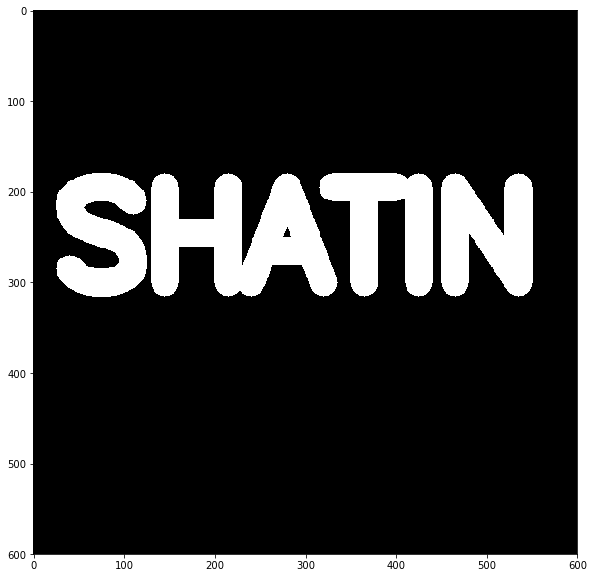

In [4]:
img = load_img()
show_img(img)

# Erosion

In [5]:
kernel = np.ones(shape=(5,5), dtype=np.uint8)

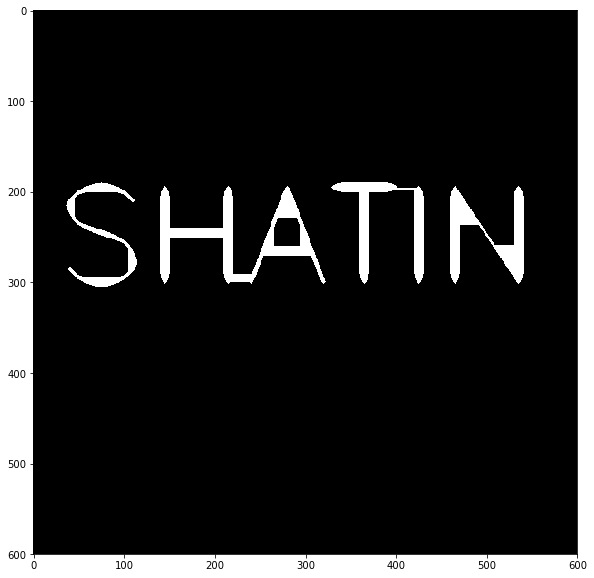

In [6]:
dst = cv2.erode(img, kernel, iterations=5)
show_img(dst)

# Morphological Opening

In [7]:
# Useful for reducing white noise

In [8]:
img = load_img()

In [9]:
white_noise = np.random.randint(low=0, high=2, size=(600,600)) * 255
white_noise

array([[255,   0,   0, ...,   0, 255, 255],
       [  0,   0,   0, ..., 255,   0,   0],
       [  0,   0, 255, ..., 255, 255, 255],
       ...,
       [255, 255,   0, ...,   0,   0,   0],
       [255,   0, 255, ..., 255,   0, 255],
       [  0,   0, 255, ...,   0, 255, 255]])

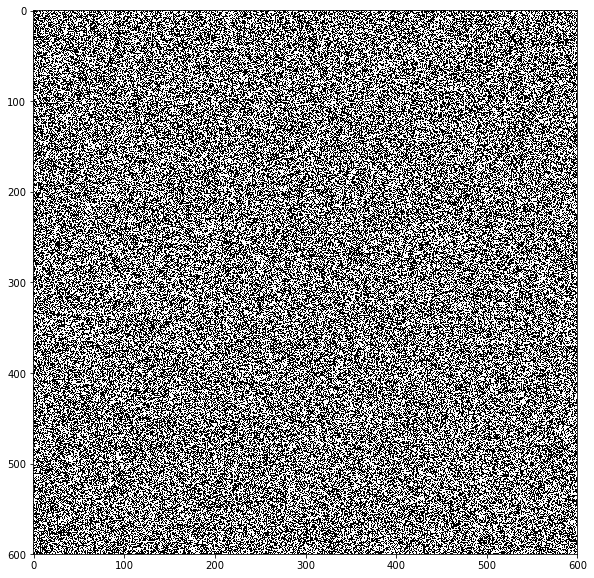

In [10]:
show_img(white_noise)

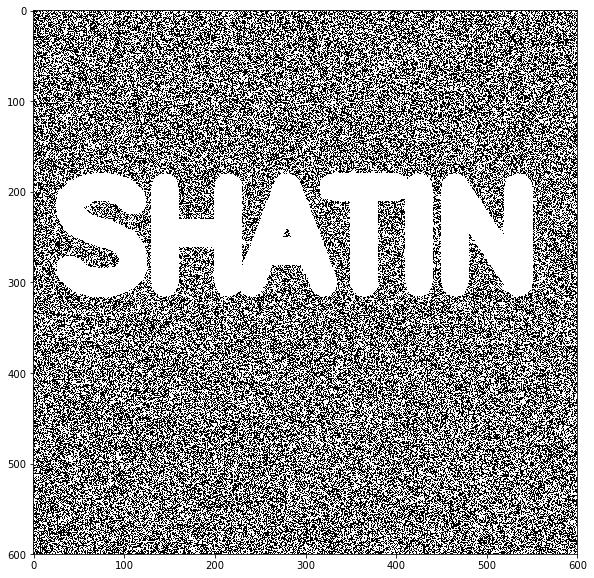

In [11]:
img_w_noise = img + white_noise
img_w_noise[img_w_noise >= 255] = 255
show_img(img_w_noise)

In [12]:
img_w_noise.max()

255.0

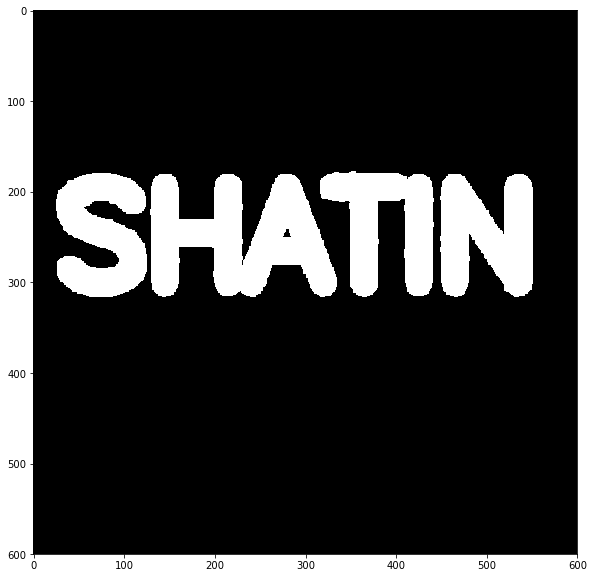

In [13]:
dst = cv2.morphologyEx(img_w_noise, cv2.MORPH_OPEN, kernel)
show_img(dst)

# Morphological Closing

In [14]:
# Useful for reducing black noise

In [15]:
img = load_img()

In [16]:
black_noise = np.random.randint(low=0, high=2, size=(600,600)) * -255

black_noise

array([[   0,    0, -255, ..., -255, -255, -255],
       [-255,    0,    0, ..., -255, -255,    0],
       [   0, -255,    0, ..., -255,    0, -255],
       ...,
       [   0,    0,    0, ..., -255,    0,    0],
       [   0,    0,    0, ...,    0,    0, -255],
       [-255, -255, -255, ...,    0,    0,    0]])

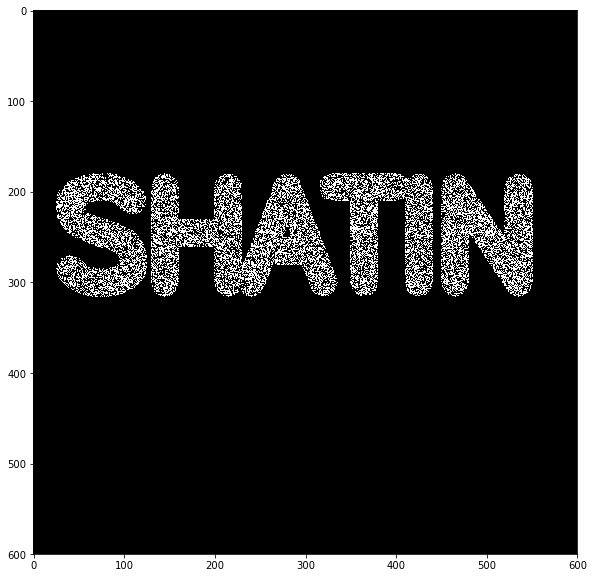

In [17]:
img_b_noise = img + black_noise
img_b_noise[img_b_noise == -255] = 0
show_img(img_b_noise)

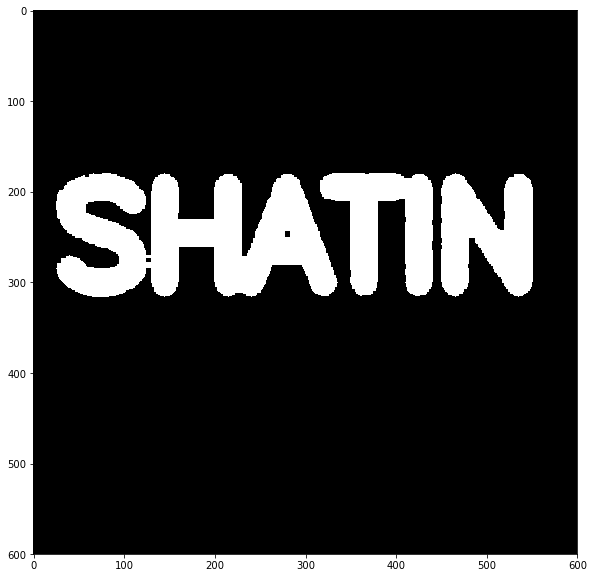

In [18]:
dst = cv2.morphologyEx(img_b_noise, cv2.MORPH_CLOSE, kernel)
show_img(dst)

# Morphological Gradient

In [19]:
# Difference between Erosion & Diltion

In [20]:
img = load_img()

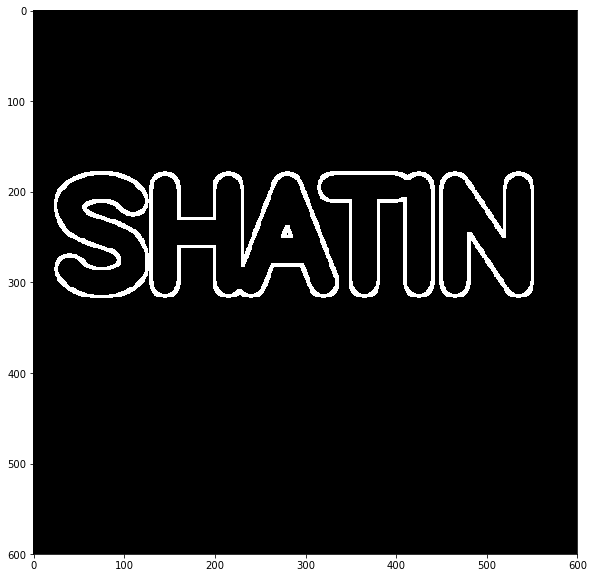

In [21]:
dst = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)
show_img(dst)